Upload all the required libraries

In [6]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import random

Set the random seed to reproduce the results

In [7]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Build class dataset as well as load image and layover the annotations to visualize the setection anchors

In [8]:
class MOT17Dataset(Dataset):
    def __init__(self, mot_root, img_size=640, detector="DPM"):
        self.img_size = img_size
        self.samples = []
        mot_root = Path(mot_root)
        sequences = sorted([
            d for d in mot_root.iterdir()
            if d.is_dir() and d.name.endswith(f"-{detector}")
        ])
        print(f"Found {len(sequences)} sequences")
        for seq_dir in sequences:
            gt_path = seq_dir / "gt" / "gt.txt"
            img_dir = seq_dir / "img1"
            if not gt_path.exists():
                continue
            frame_boxes = {}
            with open(gt_path) as f:
                for line in f:
                    parts = line.strip().split(",")
                    if len(parts) < 8:
                        continue
                    frame_id = int(parts[0])
                    conf     = int(parts[6])
                    cls      = int(parts[7])
                    if conf != 1 or cls != 1:
                        continue
                    x, y, w, h = float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5])
                    x1, y1 = max(0, x), max(0, y)
                    x2, y2 = x1 + w, y1 + h
                    if w <= 0 or h <= 0:
                        continue
                    frame_boxes.setdefault(frame_id, []).append([x1, y1, x2, y2])
            for frame_id, boxes in frame_boxes.items():
                img_path = img_dir / f"{frame_id:06d}.jpg"
                if img_path.exists():
                    self.samples.append((str(img_path), boxes))
        print(f"Total samples: {len(self.samples)}")
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img_path, boxes = self.samples[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        img = cv2.resize(img, (self.img_size, self.img_size))
        scale_x = self.img_size / w
        scale_y = self.img_size / h
        scaled_boxes = []
        for (x1, y1, x2, y2) in boxes:
            x1 = min(x1 * scale_x, self.img_size - 1)
            y1 = min(y1 * scale_y, self.img_size - 1)
            x2 = min(x2 * scale_x, self.img_size - 1)
            y2 = min(y2 * scale_y, self.img_size - 1)
            if x2 > x1 and y2 > y1:
                scaled_boxes.append([x1, y1, x2, y2])
        img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        if len(scaled_boxes) == 0:
            boxes_tensor  = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,),   dtype=torch.int64)
        else:
            boxes_tensor  = torch.tensor(scaled_boxes, dtype=torch.float32)
            labels_tensor = torch.ones(len(scaled_boxes), dtype=torch.int64)  # 1 = person
        target = {
            "boxes":  boxes_tensor,
            "labels": labels_tensor,
        }
        return img, target

Function to pass the folder path which contains files and annotations, to plot the image along with the type of annotations

Found 7 sequences
Total samples: 5316
Image shape: torch.Size([3, 640, 640])
Boxes: tensor([[446.0000, 247.7037, 501.6667, 472.2963],
        [195.3333, 264.8889, 223.6667, 420.7408],
        [472.0000, 255.4074, 533.3333, 454.5185]])
Labels: tensor([1, 1, 1])
x2>x1: tensor(True)
y2>y1: tensor(True)


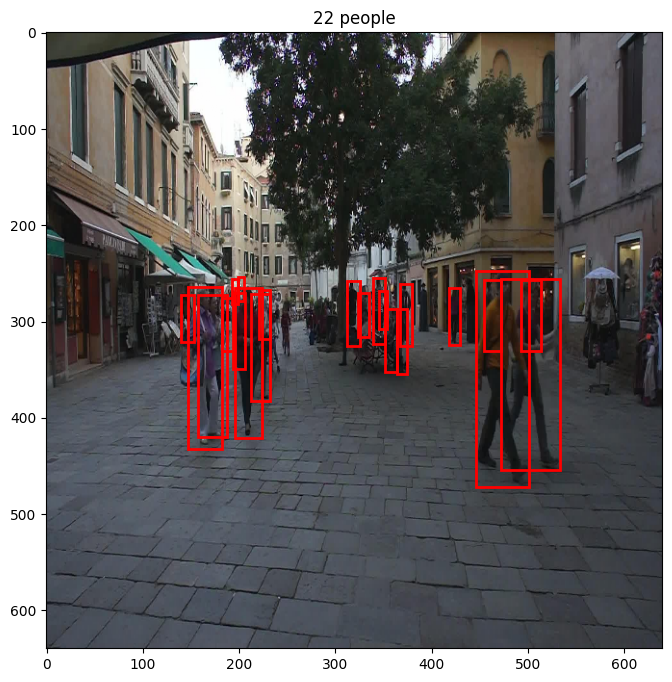

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

MOT_ROOT = "/content/drive/MyDrive/train"

dataset = MOT17Dataset(MOT_ROOT, img_size=640)
img, target = dataset[0]
print("Image shape:", img.shape)
print("Boxes:", target['boxes'][:3])
print("Labels:", target['labels'][:3])
print("x2>x1:", (target['boxes'][:,2] > target['boxes'][:,0]).all())
print("y2>y1:", (target['boxes'][:,3] > target['boxes'][:,1]).all())

fig, ax = plt.subplots(1, figsize=(8,8))
ax.imshow(img.permute(1,2,0))
for box in target['boxes']:
    x1,y1,x2,y2 = box
    rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                               linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
plt.title(f"{len(target['boxes'])} people")
plt.show()

Creating two separate dataloaders for the train folder and val folder , also trying to save the data for val into a folder to use it later to calculate
1. MAP
2. precision
3. recall
4. F1 score

In [12]:
from torch.utils.data import random_split, DataLoader
# Collate function
def collate_fn(batch):
    return tuple(zip(*batch))
dataset = MOT17Dataset("/content/drive/MyDrive/train", img_size=640)

# 80/20 split with fixed generator
total      = len(dataset)
train_size = int(0.8 * total)
val_size   = total - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size],
                                           generator=generator)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,
                          num_workers=2, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False,
                          num_workers=2, collate_fn=collate_fn)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Found 7 sequences
Total samples: 5316
Train: 4252 | Val: 1064


Saving the val dataset to load it later to execute mAP, precision, recall, f1-score

In [13]:
import json
import shutil
from pathlib import Path

val_save_dir = Path("/content/drive/MyDrive/val_data_with_gt")
val_save_dir.mkdir(exist_ok=True)

val_indices = list(val_dataset.indices)

with open("/content/drive/MyDrive/val_indices.txt", "w") as f:
    f.write("\n".join(map(str, val_indices)))

# Save images + gt annotations
val_annotations = {}

print("Saving val data...")
for idx in val_indices:
    img_path, boxes = dataset.samples[idx]
    img_path = Path(img_path)
    seq_name = img_path.parent.parent.name       # e.g. MOT17-02-DPM

    dst_dir = val_save_dir / seq_name / "img1"
    dst_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(img_path, dst_dir / img_path.name)

    key = f"{seq_name}/{img_path.name}"
    val_annotations[key] = boxes

# Save all gt boxes to json
with open(val_save_dir / "annotations.json", "w") as f:
    json.dump(val_annotations, f)

print(f"Done — saved {len(val_indices)} images + GT to val_data_with_gt/")

Saving val data...
Done — saved 1064 images + GT to val_data_with_gt/


In [14]:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)
model = fasterrcnn_resnet50_fpn(pretrained=True)

num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

for param in model.backbone.parameters():
    param.requires_grad = False

model.to(device)
print("Model ready")

Using: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 288MB/s]


Model ready


In [15]:
!pip install wandb
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: saniav2711 (ishaya-2716) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [17]:
import wandb
from tqdm import tqdm

# Initialize wandb
wandb.init(project="mot17-detection", name="fasterrcnn-dpm")

num_epochs = 30
optimizer  = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
best_val_loss = float('inf')

for epoch in range(num_epochs):
    print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")

    # Training
    model.train()
    epoch_loss = 0
    for imgs, targets in tqdm(train_loader, desc="Train"):
        imgs    = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        losses    = sum(loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        epoch_loss += losses.item()

    avg_train = epoch_loss / len(train_loader)
    print(f"Train Loss: {avg_train:.4f}")

    # Validation
    model.train()
    val_loss = 0
    with torch.no_grad():
        for imgs, targets in tqdm(val_loader, desc="Val"):
            imgs    = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(imgs, targets)
            val_loss += sum(loss_dict.values()).item()

    avg_val = val_loss / len(val_loader)
    print(f"Val Loss: {avg_val:.4f}")

    scheduler.step()

    # Log to wandb
    wandb.log({
        "epoch":      epoch + 1,
        "train_loss": avg_train,
        "val_loss":   avg_val,
        "lr":         optimizer.param_groups[0]['lr']
    })

    # Save best model
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), "/content/drive/MyDrive/model_weights/best_model_2.pth")
        print("Saved best model")
        wandb.save("/content/drive/MyDrive/model_weights/best_model_2.pth")

wandb.finish()

epoch,▁
lr,▁
train_loss,▁
val_loss,▁
epoch,1
lr,0.0001
train_loss,0.65475
val_loss,0.56885



===== Epoch 1/30 =====


Train: 100%|██████████| 1063/1063 [00:52<00:00, 20.43it/s]


Train Loss: 0.5360


Val: 100%|██████████| 266/266 [00:10<00:00, 24.48it/s]
wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


...

Train: 100%|██████████| 1063/1063 [00:53<00:00, 19.91it/s]


Train Loss: 0.3091


Val: 100%|██████████| 266/266 [00:11<00:00, 24.13it/s]

Val Loss: 0.3759


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,██▄▄▄▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▆▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▅▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
lr,0.0
train_loss,0.30909
val_loss,0.37589


Visualization

In [20]:
import torch
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rebuild model
model = fasterrcnn_resnet50_fpn(pretrained=False)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)

# Load saved weights
model.load_state_dict(torch.load("/content/drive/MyDrive/model_weights/best_model_2.pth", map_location=device))
model.to(device)
model.eval()
print("Model loaded successfully")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 97.0MB/s]


Model loaded successfully


In [21]:
with open("/content/drive/MyDrive/val_data_with_gt/annotations.json") as f:
    val_annotations = json.load(f)

val_dir     = Path("/content/drive/MyDrive/val_data_with_gt")
val_samples = []

for key, boxes in val_annotations.items():
    img_path = val_dir / key
    val_samples.append((str(img_path), boxes))

print(f"Loaded {len(val_samples)} val samples")

Loaded 1064 val samples


In [22]:
class ValGTDataset(Dataset):
    def __init__(self, samples, img_size=640):
        self.samples  = samples
        self.img_size = img_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, boxes = self.samples[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        img  = cv2.resize(img, (self.img_size, self.img_size))
        scale_x = self.img_size / w
        scale_y = self.img_size / h
        scaled_boxes = []
        for (x1, y1, x2, y2) in boxes:
            x1 = min(x1 * scale_x, self.img_size - 1)
            y1 = min(y1 * scale_y, self.img_size - 1)
            x2 = min(x2 * scale_x, self.img_size - 1)
            y2 = min(y2 * scale_y, self.img_size - 1)
            if x2 > x1 and y2 > y1:
                scaled_boxes.append([x1, y1, x2, y2])
        img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        if len(scaled_boxes) == 0:
            boxes_tensor  = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,),   dtype=torch.int64)
        else:
            boxes_tensor  = torch.tensor(scaled_boxes, dtype=torch.float32)
            labels_tensor = torch.ones(len(scaled_boxes), dtype=torch.int64)
        return img, {"boxes": boxes_tensor, "labels": labels_tensor}

def collate_fn(batch):
    return tuple(zip(*batch))

val_gt_dataset = ValGTDataset(val_samples, img_size=640)
val_gt_loader  = DataLoader(val_gt_dataset, batch_size=4, shuffle=False,
                             num_workers=2, collate_fn=collate_fn)
print(f"Val loader ready — {len(val_gt_dataset)} images")

Val loader ready — 1064 images


In [23]:
def evaluate_map(model, data_loader, device):
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox")

    with torch.no_grad():
        for imgs, targets in tqdm(data_loader, desc="Evaluating"):
            imgs = [img.to(device) for img in imgs]
            outputs = model(imgs)

            preds = [{
                "boxes":  o["boxes"].cpu(),
                "scores": o["scores"].cpu(),
                "labels": o["labels"].cpu()
            } for o in outputs]

            tgts = [{
                "boxes":  t["boxes"].cpu(),
                "labels": t["labels"].cpu()
            } for t in targets]

            metric.update(preds, tgts)

    results = metric.compute()
    print(f"\n{'='*40}")
    print(f"mAP@0.50:      {results['map_50']:.4f}")
    print(f"mAP@0.50:0.95: {results['map']:.4f}")
    print(f"Precision:     {results['map_per_class']}")
    print(f"mAR@100:       {results['mar_100']:.4f}")
    print(f"{'='*40}")
    return results

results = evaluate_map(model, val_gt_loader, device)

Evaluating:   0%|          | 0/266 [00:00<?, ?it/s]


error: Caught error in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_7275/887782783.py", line 12, in __getitem__
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
cv2.error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'



In [24]:
with open("/content/drive/MyDrive/val_data_with_gt/annotations.json") as f:
    val_annotations = json.load(f)

# Check what the key actually looks like
first_key = list(val_annotations.keys())[0]
print(f"Key format: {first_key}")

Key format: MOT17-04-DPM/000506.jpg


In [25]:
val_dir     = Path("/content/drive/MyDrive/val_data_with_gt")
val_samples = []

for key, boxes in val_annotations.items():
    parts    = key.split("/")               # ["MOT17-04-DPM", "000506.jpg"]
    seq_name = parts[0]                     # "MOT17-04-DPM"
    fname    = parts[1]                     # "000506.jpg"
    img_path = val_dir / seq_name / "img1" / fname

    if img_path.exists():
        val_samples.append((str(img_path), boxes))
    else:
        print(f"Missing: {img_path}")

print(f"Valid samples: {len(val_samples)}")

Valid samples: 1064


In [26]:
val_gt_dataset = ValGTDataset(val_samples, img_size=640)
val_gt_loader  = DataLoader(val_gt_dataset, batch_size=4, shuffle=False,
                             num_workers=2, collate_fn=collate_fn)
print(f"Val loader ready — {len(val_gt_dataset)} images")

Val loader ready — 1064 images


In [27]:
results = evaluate_map(model, val_gt_loader, device)

Evaluating: 100%|██████████| 266/266 [00:09<00:00, 26.76it/s]



mAP@0.50:      0.9082
mAP@0.50:0.95: 0.6753
Precision:     -1.0
mAR@100:       0.7194


In [28]:
from torchvision.ops import box_iou

def compute_precision_recall_f1(model, data_loader, device,
                                  score_thresh=0.5, iou_thresh=0.5):
    model.eval()
    TP, FP, FN = 0, 0, 0

    with torch.no_grad():
        for imgs, targets in tqdm(data_loader, desc="P/R/F1"):
            imgs    = [img.to(device) for img in imgs]
            outputs = model(imgs)

            for output, target in zip(outputs, targets):
                pred_boxes   = output["boxes"][output["scores"] >= score_thresh].cpu()
                target_boxes = target["boxes"].cpu()

                if len(target_boxes) == 0 and len(pred_boxes) == 0:
                    continue
                elif len(target_boxes) == 0:
                    FP += len(pred_boxes)
                    continue
                elif len(pred_boxes) == 0:
                    FN += len(target_boxes)
                    continue

                iou_matrix     = box_iou(pred_boxes, target_boxes)
                matched_targets = set()

                for i in range(len(pred_boxes)):
                    best_iou = iou_matrix[i].max().item()
                    best_j   = iou_matrix[i].argmax().item()
                    if best_iou >= iou_thresh and best_j not in matched_targets:
                        TP += 1
                        matched_targets.add(best_j)
                    else:
                        FP += 1

                FN += len(target_boxes) - len(matched_targets)

    precision = TP / (TP + FP + 1e-6)
    recall    = TP / (TP + FN + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)

    print(f"\n{'='*40}")
    print(f"TP: {TP} | FP: {FP} | FN: {FN}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"{'='*40}")

    return precision, recall, f1

precision, recall, f1 = compute_precision_recall_f1(model, val_gt_loader, device)

P/R/F1: 100%|██████████| 266/266 [00:10<00:00, 26.57it/s]


TP: 19727 | FP: 3664 | FN: 2153
Precision: 0.8434
Recall:    0.9016
F1 Score:  0.8715


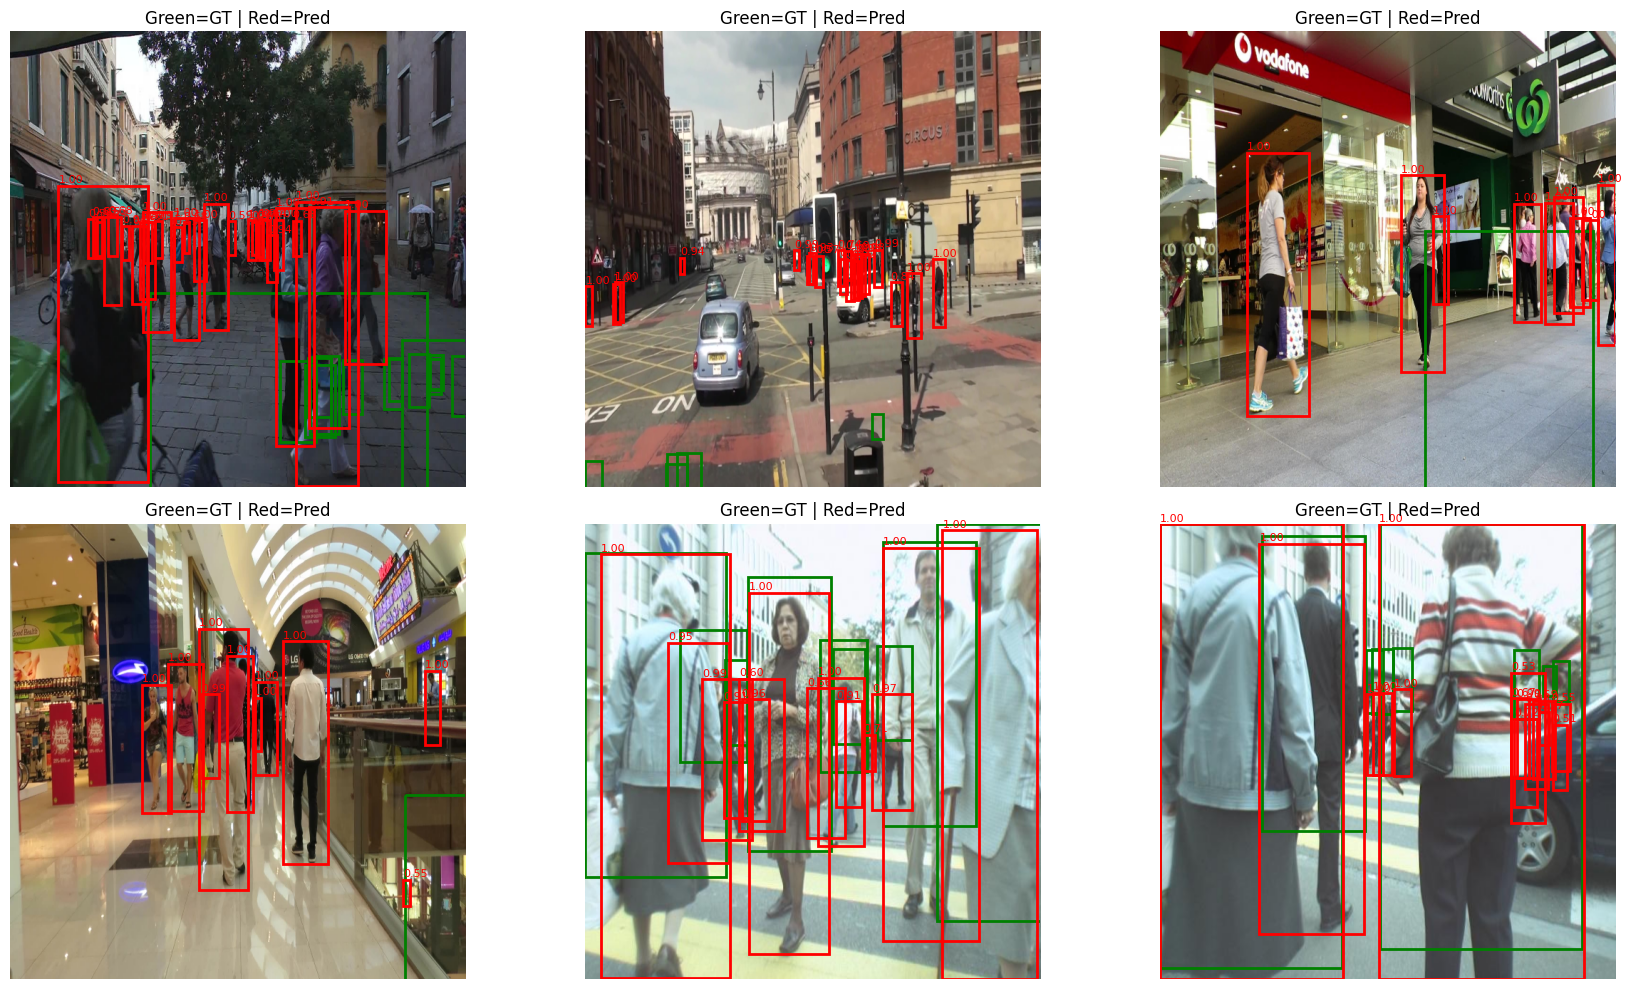

In [29]:
import random

model.eval()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

samples_to_show = random.sample(val_samples, 6)

for ax, (img_path, gt_boxes) in zip(axes.flatten(), samples_to_show):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    img  = cv2.resize(img, (640, 640))

    tensor = torch.tensor(img).permute(2, 0, 1).float() / 255.0

    with torch.no_grad():
        output = model([tensor.to(device)])[0]

    ax.imshow(img)

    # Green = Ground Truth
    for (x1, y1, x2, y2) in gt_boxes:
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor='green', facecolor='none')
        ax.add_patch(rect)

    # Red = Predictions
    for box, score in zip(output["boxes"].cpu(), output["scores"].cpu()):
        if score >= 0.5:
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"{score:.2f}", color='red', fontsize=8)

    ax.set_title(f"Green=GT | Red=Pred")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
!pip install torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.7 MB/s eta 0:00:00
